# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [123]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [124]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [462]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数（包含自适应参数）

In [502]:
instrument_id = '511090'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_adaptive',
    'stride': 1,

    'short_window': 300,
    'long_window': 600,
    'y_window': 600,

    'open_threshold': 3,  
    'open_confidence': 0,  

    'standard_num': 1000,

    'atr_multiplier': 4,
    'vol_window': 600,
    
    'k_up': 3,
    'k_down': 3,
    "stop_tighten_start": 3000,
    'stop_tighten_step' : 6000,
    'stop_tighten_factor': 1,
    'stop_tighten_floor': 0.75,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [503]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

# 方法1: 使用天数分割（原来的方法）
# train_dates, valid_dates, test_dates = split_dates(trade_dates,45,15,17)

# 方法2: 使用日期范围分割（新的灵活方法）
train_dates, valid_dates, test_dates = split_dates_by_range(
    trade_dates,
    train_start="20250901",  # 训练集开始日期
    train_end="20260228",    # 训练集结束日期
    valid_start="20251201",  # 验证集开始日期
    valid_end="20251201",    # 验证集结束日期
    test_start="20260301",   # 测试集开始日期
    test_end="20261231"      # 测试集结束日期
)
'''train_dates, valid_dates, test_dates = trade_dates,valid_dates,test_dates = split_dates_randomly(    
    trade_dates,
    test_days_min=30,
    valid_days=1,
    random_seed=6262,
    shuffle=True)'''

总交易日数量: 74
交易日范围: 20250901 ~ 20260409
训练集: 20250901 ~ 20260227 (59天)
验证集: 20251201 ~ 20251201 (1天)
测试集: 20260303 ~ 20260409 (15天)


'train_dates, valid_dates, test_dates = trade_dates,valid_dates,test_dates = split_dates_randomly(    \n    trade_dates,\n    test_days_min=30,\n    valid_days=1,\n    random_seed=6262,\n    shuffle=True)'

## 生成训练数据

In [504]:
print("生成训练集样本...")
X_train, y_train , feature_names= samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")

生成训练集样本...
20250901: 产生 274 个样本
20250903: 产生 297 个样本
20250905: 产生 268 个样本
20250909: 产生 282 个样本
20250911: 产生 243 个样本
20250915: 产生 270 个样本
20250917: 产生 249 个样本
20250919: 产生 275 个样本
20250923: 产生 274 个样本
20250925: 产生 286 个样本
20250929: 产生 276 个样本
20251009: 产生 279 个样本
20251013: 产生 230 个样本
20251015: 产生 240 个样本
20251017: 产生 240 个样本
20251021: 产生 296 个样本
20251023: 产生 256 个样本
20251027: 产生 276 个样本
20251029: 产生 284 个样本
20251031: 产生 282 个样本
20251103: 产生 288 个样本
20251105: 产生 282 个样本
20251107: 产生 275 个样本
20251111: 产生 274 个样本
20251113: 产生 288 个样本
20251117: 产生 309 个样本
20251119: 产生 279 个样本
20251121: 产生 276 个样本
20251125: 产生 282 个样本
20251127: 产生 302 个样本
20251201: 产生 324 个样本
20251203: 产生 334 个样本
20251205: 产生 275 个样本
20251209: 产生 292 个样本
20251211: 产生 301 个样本
20251215: 产生 304 个样本
20251217: 产生 292 个样本
20251219: 产生 295 个样本
20251223: 产生 296 个样本
20251225: 产生 340 个样本
20251229: 产生 261 个样本
20251231: 产生 285 个样本
20260105: 产生 308 个样本
20260107: 产生 286 个样本
20260109: 产生 275 个样本
20260113: 产生 273 个样本
20260115: 产生 305 个样本
20

In [505]:
print("生成验证集样本...")
X_valid, y_valid , __= samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")

生成验证集样本...
20251201: 产生 324 个样本
验证集样本: X=(324, 12), y=(324,)


In [506]:
print("生成测试集样本...")
X_test, y_test ,__= samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")

生成测试集样本...
20260303: 产生 331 个样本
20260305: 产生 363 个样本
20260309: 产生 316 个样本
20260311: 产生 331 个样本
20260313: 产生 333 个样本
20260317: 产生 339 个样本
20260319: 产生 307 个样本
20260323: 产生 321 个样本
20260325: 产生 369 个样本
20260327: 产生 375 个样本
20260331: 产生 342 个样本
20260401: 产生 356 个样本
20260403: 产生 364 个样本
20260407: 产生 330 个样本
20260409: 产生 379 个样本
测试集样本: X=(5156, 12), y=(5156,)


In [507]:
X_valid = X_test
y_valid = y_test

## 训练模型

In [508]:
model = train_model(X_train, y_train, X_valid, y_valid, param_dict , feature_names)

训练 xgboost 模型...
[0]	validation_0-logloss:0.69290
[100]	validation_0-logloss:0.69435
[200]	validation_0-logloss:0.69893
[300]	validation_0-logloss:0.70141
[400]	validation_0-logloss:0.70220
[500]	validation_0-logloss:0.70372


[600]	validation_0-logloss:0.70509
[700]	validation_0-logloss:0.70825
[800]	validation_0-logloss:0.70790
[900]	validation_0-logloss:0.70963
[999]	validation_0-logloss:0.71073
阈值优化完成: Best Threshold=0.6389, F0.5=0.4544

特征重要性（前10个）:
volatility    0.254644
alpha_07      0.103517
alpha_06      0.089494
WAMP          0.081098
alpha_04      0.077180
alpha_01      0.067763
spread        0.056688
alpha_03      0.055461
alpha_02      0.054940
alpha_05      0.054642
dtype: float32

XGBoost特征重要性详情:

Gain重要性排名:
       feature       gain
1   volatility  58.021645
11    alpha_07  23.586872
10    alpha_06  20.391634
3         WAMP  18.478502
8     alpha_04  17.585758
5     alpha_01  15.439991
2       spread  12.916527
7     alpha_03  12.637120
6     alpha_02  12.518193
9     alpha_05  12.450386
4       volume  12.378673
0   num_trades  11.448772

Weight重要性排名:
       feature  weight
3         WAMP  1360.0
1   volatility  1351.0
8     alpha_04   763.0
11    alpha_07   488.0
10    alpha_06   439.0
9   

In [509]:
# 保存模型
model_path = f"/home/jovyan/work/model/delta_{instrument_id}_dev.pkl"
import joblib
joblib.dump(model, model_path)
print(f"模型已保存到: {model_path}")

模型已保存到: /home/jovyan/work/model/delta_511090_dev.pkl


## 测试模型

测试集准确率: 0.6637

分类报告:
              precision    recall  f1-score   support

           0       0.80      0.71      0.75      3669
           1       0.43      0.55      0.49      1487

    accuracy                           0.66      5156
   macro avg       0.62      0.63      0.62      5156
weighted avg       0.69      0.66      0.67      5156


PR曲线AUC: 0.4422
平均精度 (AP): 0.4426

预测概率统计:
  均值: 0.5515
  标准差: 0.1575
  最小值: 0.0136
  25%分位数: 0.4565
  中位数: 0.5873
  75%分位数: 0.6829
  最大值: 0.8130

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.5230, 标准差=0.1625
  标签1 (正类): 均值=0.6221, 标准差=0.1179


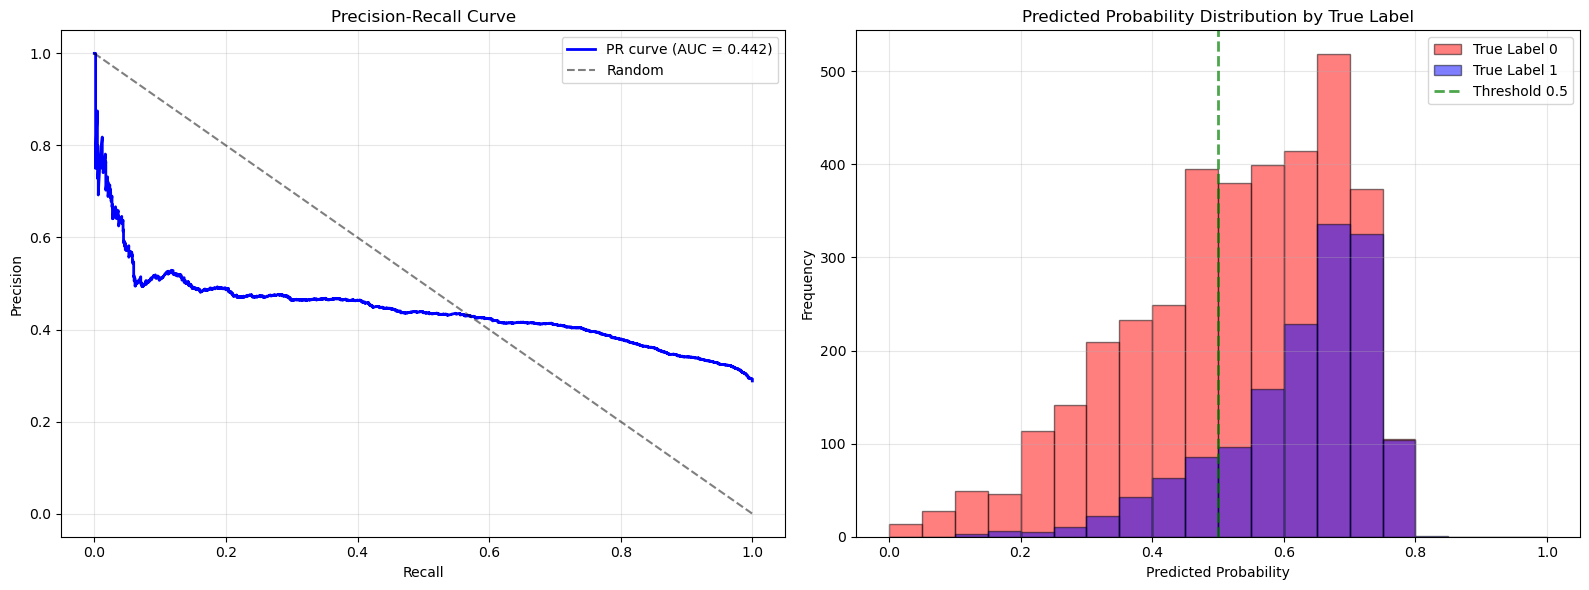

In [510]:
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)

## 创建策略实例

In [511]:
model_path = f"/home/jovyan/work/model/delta_{instrument_id}_dev.pkl"
strategy = StrategyDemo(model_path, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1_adaptive


## 使用backtesting工具进行回测

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 74 个有数据的交易日
-> 过滤后剩余 15 个有数据的交易日
-> 过滤掉 291 个无数据日期: ['20260301', '20260302', '20260304', '20260306', '20260307', '20260308', '20260310', '20260312', '20260314', '20260315']...
-> 回测标的: 511090 (20260301 - 20261231)
-> 任务分配: 共 15 天，使用 4 个核心并行计算...


[SpawnPoolWorker-411] 日期 20260325 完成 | 盈亏: -3.50 | 成交: 13次 | 胜率: 30.8% | 平均持仓: 726.5快照
[SpawnPoolWorker-409] 日期 20260303 完成 | 盈亏: -11.90 | 成交: 12次 | 胜率: 16.7% | 平均持仓: 542.7快照
[SpawnPoolWorker-410] 日期 20260313 完成 | 盈亏: -0.50 | 成交: 12次 | 胜率: 25.0% | 平均持仓: 879.5快照
[SpawnPoolWorker-412] 日期 20260403 完成 | 盈亏: 11.30 | 成交: 11次 | 胜率: 36.4% | 平均持仓: 795.5快照
[SpawnPoolWorker-409] 日期 20260305 完成 | 盈亏: -11.10 | 成交: 9次 | 胜率: 33.3% | 平均持仓: 572.4快照
[SpawnPoolWorker-412] 日期 20260407 完成 | 盈亏: 3.80 | 成交: 11次 | 胜率: 36.4% | 平均持仓: 888.0快照
[SpawnPoolWorker-411] 日期 20260327 完成 | 盈亏: -28.90 | 成交: 15次 | 胜率: 26.7% | 平均持仓: 569.1快照
[SpawnPoolWorker-410] 日期 20260317 完成 | 盈亏: -1.00 | 成交: 15次 | 胜率: 33.3% | 平均持仓: 557.4快照
[SpawnPoolWorker-411] 日期 20260331 完成 | 盈亏: -18.50 | 成交: 11次 | 胜率: 36.4% | 平均持仓: 704.2快照
[SpawnPoolWorker-412] 日期 20260409 完成 | 盈亏: 21.60 | 成交: 10次 | 胜率: 70.0% | 平均持仓: 943.6快照
[SpawnPoolWorker-409] 日期 20260309 完成 | 盈亏: 42.30 | 成交: 4次 | 胜率: 75.0% | 平均持仓: 1976.0快照
[SpawnPoolWorker-410] 日期 20260319 完成 | 盈亏

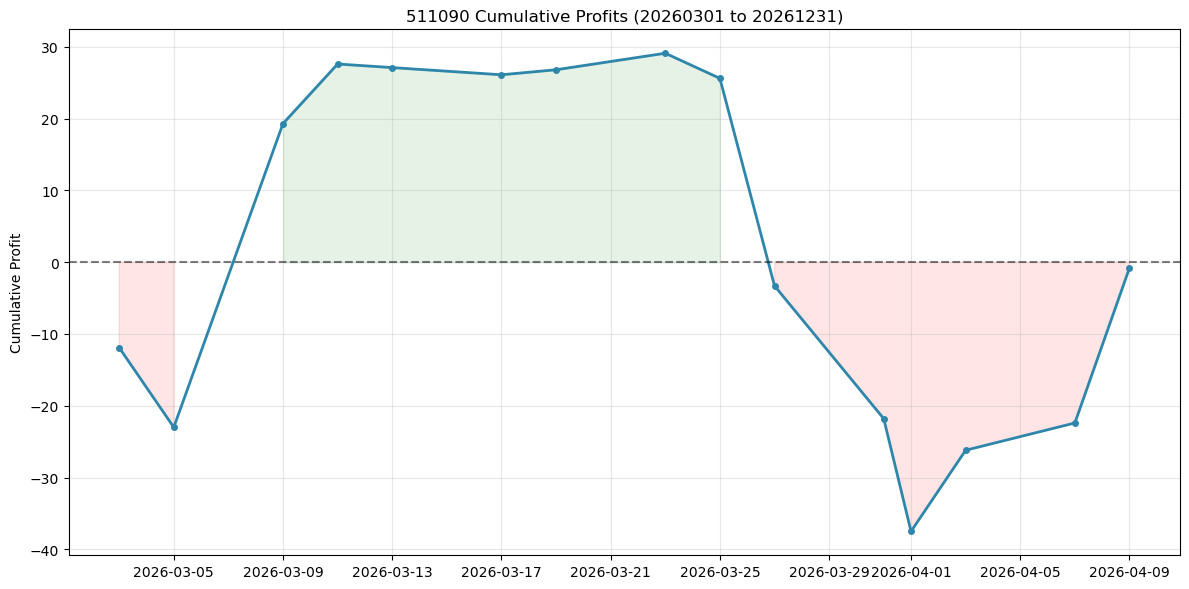


并行回测结果汇总:
{'测试天数': 15, '累计总盈亏': np.float64(-0.8), '总成交次数': 165, '盈利交易次数': 58, '亏损交易次数': 107, '加权每手胜率%': np.float64(35.15), '日均盈亏': np.float64(-0.05), '胜率(天)%': 46.67, '盈亏比(日均)': np.float64(1.13), '最大单日盈利': 42.3, '最大单日亏损': -28.9, '每笔交易平均盈利': np.float64(-0.0), '加权平均持仓时间(快照)': np.float64(747.8)}


In [513]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20260301",
    end_ymd="20261231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)
print(summary)

## 延迟回测结果

In [ ]:
from delay_stability_test import batch_delay_stability_test
batch_delay_stability_test(
    instrument_id,
    "20251201",
    "20251231",
    StrategyDemo,
    model_path,
    param_dict,
    [0,1,2,4,8,16,32,64,128,256,512,1024],
    
)

## 保存回测结果

In [499]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果

result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/backtest_result/511130_delta_v1_adaptive_20260424_092723
回测结果已保存到: /home/jovyan/work/tactics_demo/backtest_result/511130_delta_v1_adaptive_20260424_092723
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [362]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260413", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("511520", "20260420", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹
已删除: /home/jovyan/work/tactics_demo/backtest_result/511520_delta_v1_adaptive_20260420_062243

总共删除了 1 个文件夹


## 单日回测观察

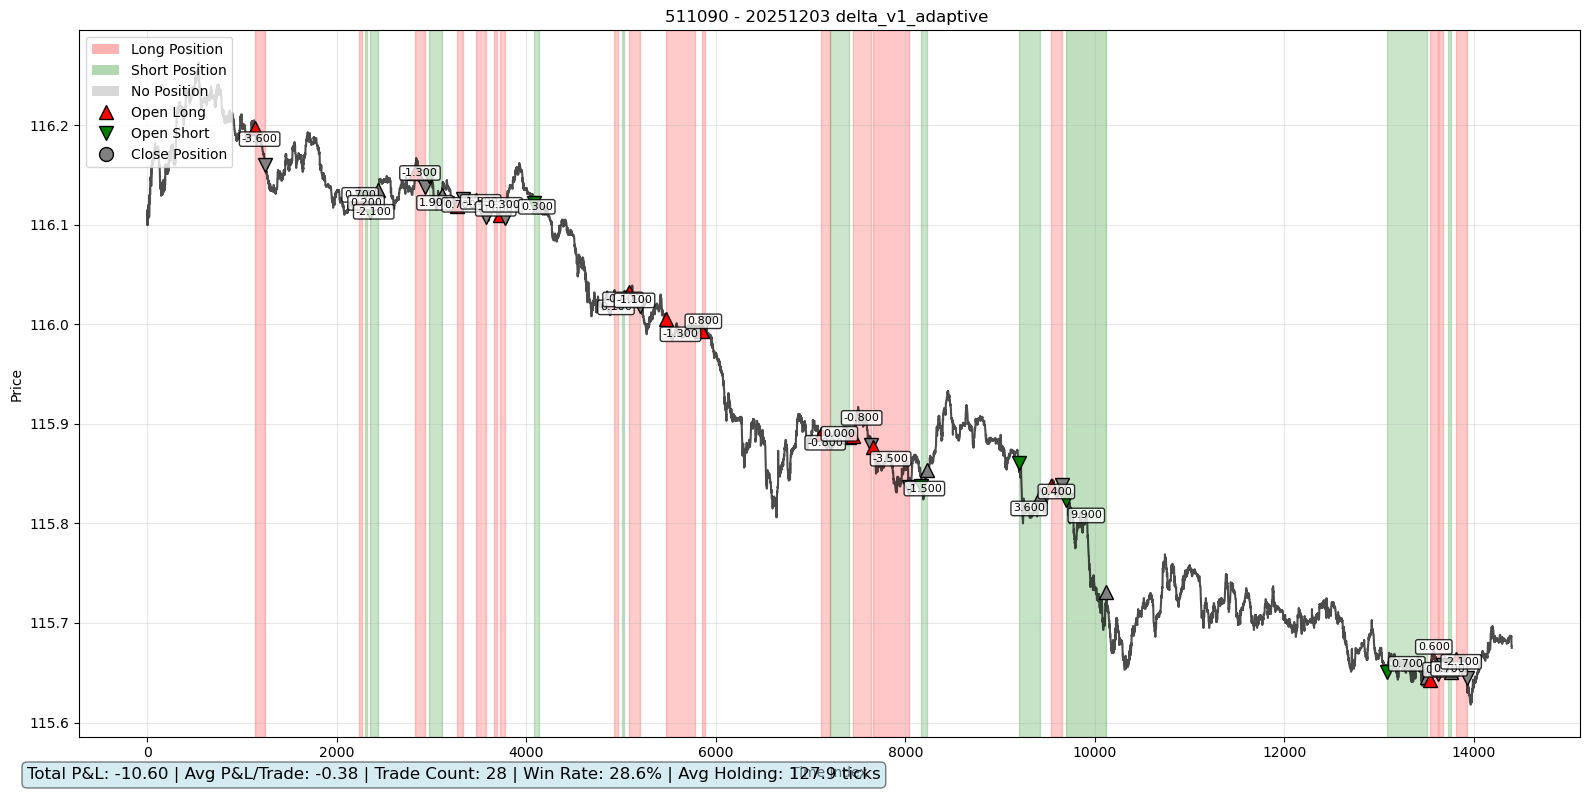

In [349]:
from single_day_backtest import single_day_backtest,plot_delta_history
strategy = StrategyDemo(model_path, param_dict)
hh = single_day_backtest(instrument_id,'20251203',StrategyDemo,model_path,param_dict,official = False)

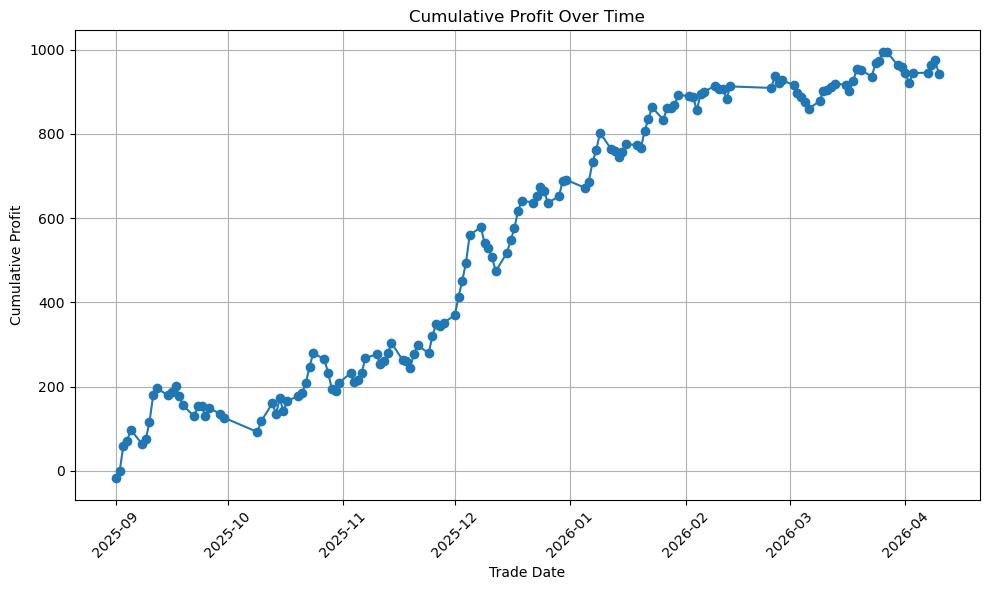

In [20]:
summary = pd.read_csv('/home/jovyan/work/live_trading/511090_20260421_oyyb_01.csv')
# plot cumulative profits

summary['cumulative_profit'] = summary['profits'].cumsum()
summary['trade_ymd'] = pd.to_datetime(summary['trade_ymd'], format='%Y%m%d')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(summary['trade_ymd'], summary['cumulative_profit'], marker='o')
plt.title('Cumulative Profit Over Time')
plt.xlabel('Trade Date')
plt.ylabel('Cumulative Profit')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
